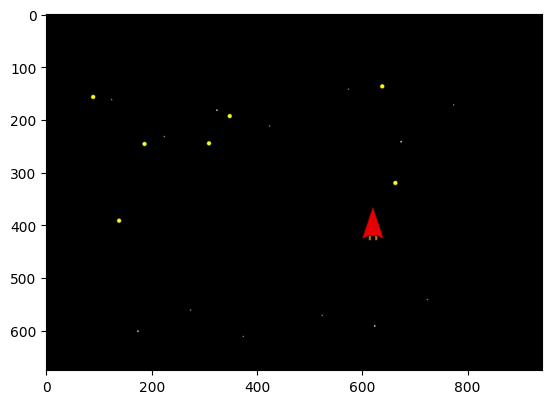

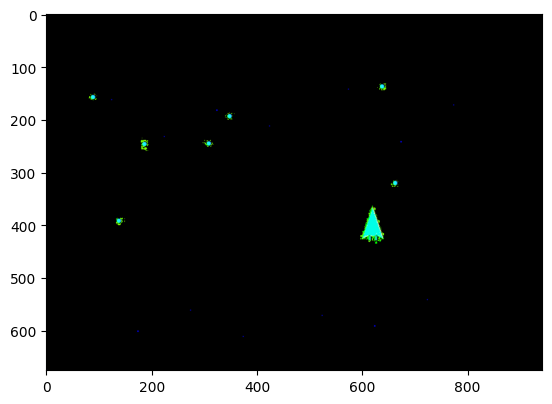

In [2]:
from matplotlib import pyplot as plt
import numpy as np
import cv2

img = cv2.imread("imgs/img.png")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

plt.imshow(img_rgb); plt.show()
plt.imshow(img_hsv); plt.show()

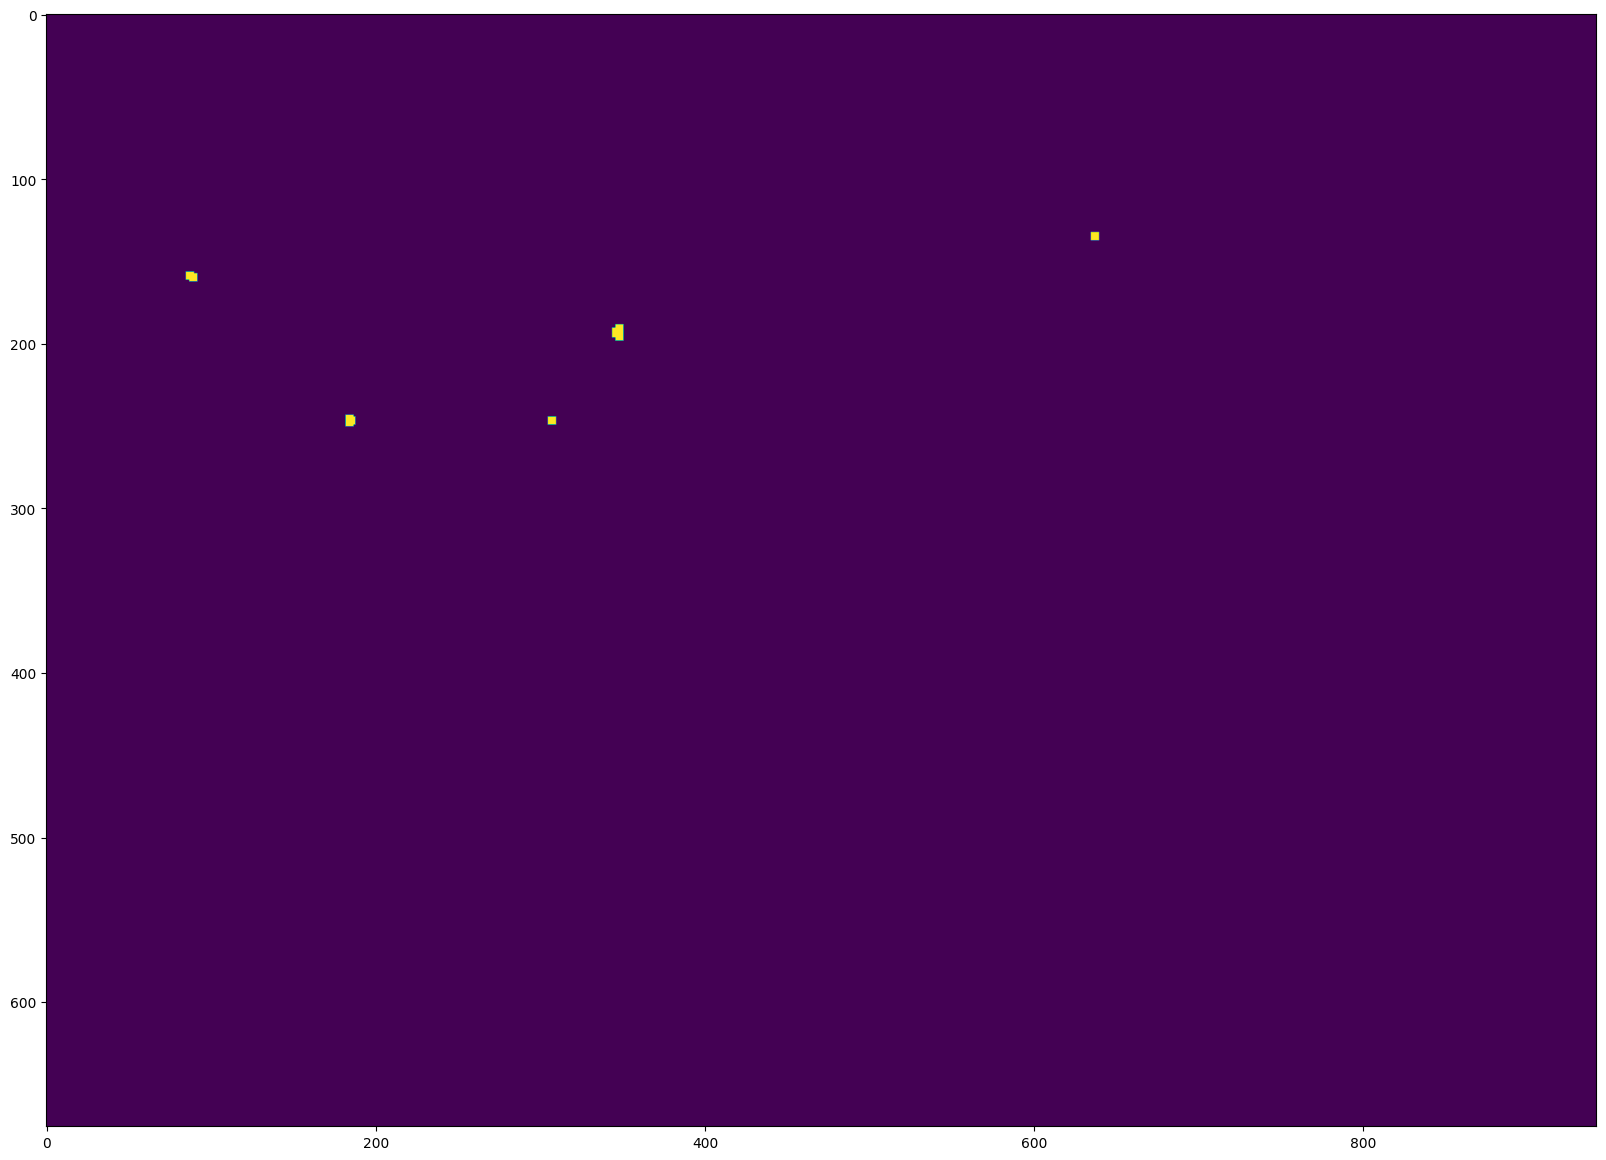

In [3]:
import numpy as np

hsv_min_yellow = np.array([22, 250, 215])
hsv_max_yellow = np.array([30, 255, 255])

mask_yellow = cv2.inRange(img_hsv, hsv_min_yellow, hsv_max_yellow)

kernel = np.ones((5,5), np.uint8)
mask_yellow = cv2.dilate(mask_yellow, kernel)

plt.figure(figsize=(20,20))
plt.imshow(mask_yellow)
plt.show()

In [1]:
from matplotlib import pyplot as plt
import numpy as np
import cv2

hsv_min_red1 = np.array([0, 100, 100])
hsv_max_red1 = np.array([10, 255, 255])
hsv_min_red2 = np.array([160, 100, 100])
hsv_max_red2 = np.array([180, 255, 255])

hsv_min_white = np.array([0, 0, 200])
hsv_max_white = np.array([180, 40, 255])

kernel = np.ones((5,5), np.uint8)

plt.figure(figsize=(20,20))
plt.imshow(mask_yellow)
plt.show()

mask_red1 = cv2.inRange(img_hsv, hsv_min_red1, hsv_max_red1)
mask_red2 = cv2.inRange(img_hsv, hsv_min_red2, hsv_max_red2)
mask_red = cv2.bitwise_or(mask_red1, mask_red2)
mask_red = cv2.dilate(mask_red, kernel)

contours_red, _ = cv2.findContours(mask_red, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
len(contours_red)

largest = max(contours_red, key=cv2.contourArea)
cv2.contourArea(largest)
box = cv2.boundingRect(largest)

x,y,w,h = box
margin = 20
x1 = max(0, x - margin)
y1 = max(0, y - margin)
x2 = min(img_hsv.shape[1], x + w + margin)
y2 = min(img_hsv.shape[0], y + h + margin)

NameError: name 'mask_yellow' is not defined

<Figure size 2000x2000 with 0 Axes>

In [ ]:
from matplotlib import pyplot as plt
import numpy as np
import cv2

cap = cv2.VideoCapture("imgs/nave1.mov")
if not cap.isOpened():
    print("Erro: Não foi possível abrir o vídeo")

hsv_min_red1 = np.array([0, 100, 100])
hsv_max_red1 = np.array([10, 255, 255])
hsv_min_red2 = np.array([160, 100, 100])
hsv_max_red2 = np.array([180, 255, 255])

hsv_min_white = np.array([0, 0, 200])
hsv_max_white = np.array([180, 40, 255])

kernel = np.ones((5, 5), np.uint8)

collision_count = 0
collision_active = False
ship_bbox = None

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.flip(frame, 1)
    frame_hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    mask_red1 = cv2.inRange(frame_hsv, hsv_min_red1, hsv_max_red1)
    mask_red2 = cv2.inRange(frame_hsv, hsv_min_red2, hsv_max_red2)
    mask_red = cv2.bitwise_or(mask_red1, mask_red2)
    mask_red = cv2.dilate(mask_red, kernel)

    contours_red, _ = cv2.findContours(mask_red, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours_red:
        largest = max(contours_red, key=cv2.contourArea)
        if cv2.contourArea(largest) > 500:
            ship_bbox = cv2.boundingRect(largest)

    has_white = False
    if ship_bbox is not None:
        x, y, w, h = ship_bbox
        margin = 20
        x1 = max(0, x - margin)
        y1 = max(0, y - margin)
        x2 = min(frame.shape[1], x + w + margin)
        y2 = min(frame.shape[0], y + h + margin)

        roi_hsv = frame_hsv[y1:y2, x1:x2]
        mask_white_roi = cv2.inRange(roi_hsv, hsv_min_white, hsv_max_white)
        has_white = np.sum(mask_white_roi > 0) > 300

        cv2.rectangle(frame, (x1, y1), (x2, y2), (255, 0, 0), 2)
        
        print(collision_active)

    if has_white and not collision_active:
        collision_count += 1
        collision_active = True
    elif not has_white:
        collision_active = False

    cv2.putText(frame, f"Colisoes: {collision_count}", (20, 50),
                cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 255, 0), 3)

    cv2.imshow("Video", frame)
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

print(f"Total de colisoes: {collision_count}")